In [76]:
import pandas as pd

In [77]:
#train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
#test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

In [78]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

In [79]:
train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [80]:
train_df_en = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df_en = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [81]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [83]:
model = LogisticRegression(max_iter=2000)
model.fit(x_train, y_train)

preds = model.predict(x_test)

preds_t = model.predict(x_train)

In [84]:
print("Accuracy Train:", accuracy_score(y_train, preds_t))
print("Accuracy:", accuracy_score(y_test, preds))
print("F1 (macro):", f1_score(y_test, preds, average='macro'))
print(classification_report(y_test, preds))

Accuracy Train: 0.8806818181818182
Accuracy: 0.8909090909090909
F1 (macro): 0.8923065536498154
              precision    recall  f1-score   support

           0       0.87      0.88      0.87        74
           1       0.98      0.89      0.93        72
           2       0.84      0.91      0.87        74

    accuracy                           0.89       220
   macro avg       0.90      0.89      0.89       220
weighted avg       0.90      0.89      0.89       220



In [85]:
#best acuracy is 89% with for train data 88%

In [86]:
feature_cols_pca = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols_pca]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols_pca]
y_test_pca = test_df_pca["target"]

model_pca = LogisticRegression(max_iter=2000)
model_pca.fit(x_train_pca, y_train_pca)

preds_pca = model_pca.predict(x_test_pca)
preds_pca_t = model_pca.predict(x_train_pca)

print("Accuracy Train:", accuracy_score(y_train_pca, preds_pca_t))
print("Accuracy:", accuracy_score(y_test_pca, preds_pca))
print("F1 (macro):", f1_score(y_test_pca, preds_pca, average='macro'))
print(classification_report(y_test_pca, preds_pca))

Accuracy Train: 0.8772727272727273
Accuracy: 0.8818181818181818
F1 (macro): 0.8828190427790218
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        74
           1       0.96      0.89      0.92        72
           2       0.84      0.88      0.86        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



In [87]:
#for pca dataset accuracy is lower

In [88]:
#hyper parameter tuning with feature selected dataset

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [90]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg', 'saga']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_model = grid.best_estimator_
preds = best_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, preds))
print("Test F1 (macro):", f1_score(y_test, preds, average='macro'))
print(classification_report(y_test, preds))

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.878409090909091
Test Accuracy: 0.8909090909090909
Test F1 (macro): 0.8923065536498154
              precision    recall  f1-score   support

           0       0.87      0.88      0.87        74
           1       0.98      0.89      0.93        72
           2       0.84      0.91      0.87        74

    accuracy                           0.89       220
   macro avg       0.90      0.89      0.89       220
weighted avg       0.90      0.89      0.89       220



In [91]:
import joblib

joblib.dump(best_model, "../results/model_trained_files/logistic_regression_model.pkl")

['../results/model_trained_files/logistic_regression_model.pkl']

In [92]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

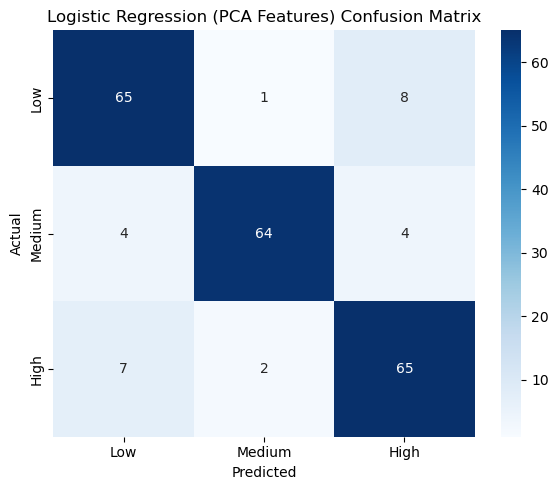

In [93]:
cm_pca = confusion_matrix(y_test_pca, preds_pca)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression (PCA Features) Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/eda_visualizations/logistic_r_pca_confusion_matrix.png", dpi=150, bbox_inches='tight')

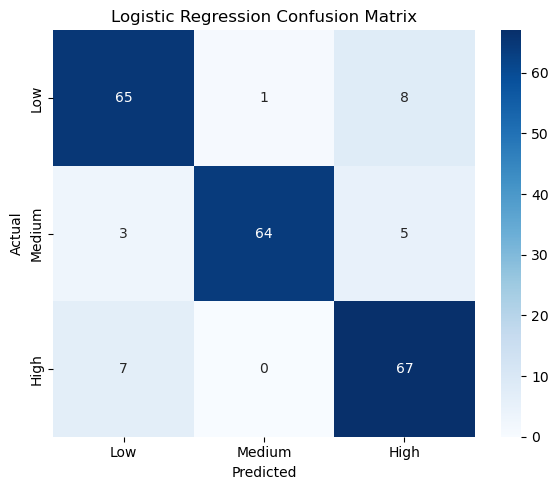

In [94]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/eda_visualizations/logistic_r_stnd_confusion_matrix.png", dpi=150, bbox_inches='tight')